In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import numpy as np
import seaborn as sns

In [2]:
def get_AUC_and_error(df, sample_type):
    df_sample = df[df['Sample Type'] == sample_type]
    AUC = df_sample['AUC-true']
    return AUC.mean(), AUC.std()

# $H \to \gamma\gamma$ channel

## Luminosity =  100, 300, 900, 1800, 3000 $\text{fb}^{-1}$

In [3]:
file_name = './GGF_VBF_training_results.csv'
df = pd.read_csv(file_name)
# df = df.query("time > '2026-03-18' and time < '2026-03-22'")

In [4]:
# 設定與圖片一致的 seaborn 樣式 (預設為無襯線字體)
sns.set_theme(style="darkgrid")

# 定義 X 軸實際數值與標籤 (改用真實數值以便正確映射 log 尺度)
x_vals = np.array([100, 300, 900, 1800, 3000])
x_labels = ['100', '300', '900', '1800', '3000']

# --- DATA  ---
# (a) With photon information
cnn_a_mean_old = np.array([0.621, 0.686, 0.725, 0.736, 0.738])
cnn_a_std_old  = np.array([0.025, 0.010, 0.005, 0.004, 0.004])

cnn_a_mean, cnn_a_std = [], []
for l in [100, 300, 900, 1800, 3000]:
    sample_type = f'quark jet: = 2, L: {l} fb^-1, aa, w/ decay product'

    mean_AUC, std_AUC = get_AUC_and_error(df, sample_type)
    cnn_a_mean.append(mean_AUC)
    cnn_a_std.append(std_AUC)

cnn_a_mean, cnn_a_std = np.array(cnn_a_mean), np.array(cnn_a_std)

cnn_fs_a_old = 0.873

sample_type = f'pure, aa, w/ decay product'
cnn_fs_a_mean, cnn_fs_a_std = get_AUC_and_error(df, sample_type)

# (b) Without photon information
cnn_b_mean_old = np.array([0.682, 0.714, 0.726, 0.730, 0.725])
cnn_b_std_old  = np.array([0.020, 0.015, 0.008, 0.006, 0.006])

cnn_b_mean, cnn_b_std = [], []
for l in [100, 300, 900, 1800, 3000]:
    sample_type = f'quark jet: = 2, L: {l} fb^-1, aa, w/o decay product'

    mean_AUC, std_AUC = get_AUC_and_error(df, sample_type)
    cnn_b_mean.append(mean_AUC)
    cnn_b_std.append(std_AUC)

cnn_b_mean, cnn_b_std = np.array(cnn_b_mean), np.array(cnn_b_std)

cnn_fs_b_old = 0.868

sample_type = f'pure, aa, w/o decay product'
cnn_fs_b_mean, cnn_fs_b_std = get_AUC_and_error(df, sample_type)

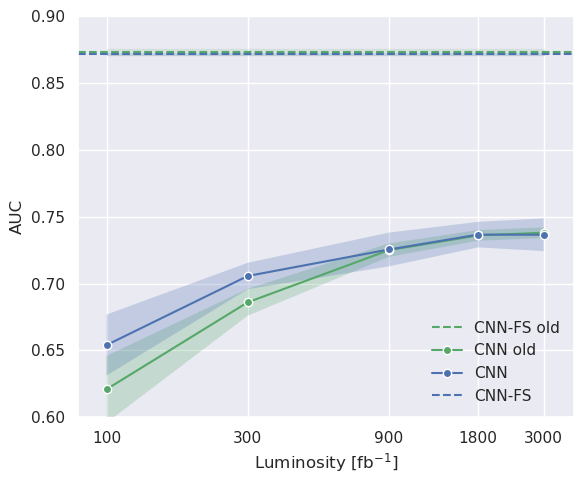

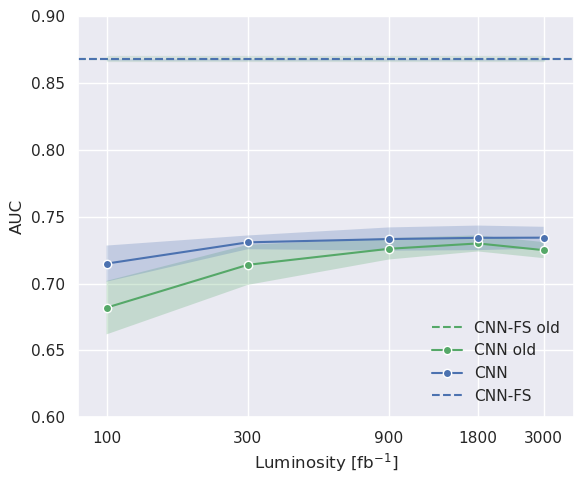

In [5]:
# 定義顏色
colors = {'CNN': '#4C72B0',
          'CNN_old': '#55A868',
        'ParT': '#DD8452'}

fig, ax = plt.subplots(figsize=(6, 5))

# 繪製原始結果
ax.axhline(y=cnn_fs_a_old, color=colors['CNN_old'], linestyle='--', label='CNN-FS old', zorder=2)
ax.fill_between(x_vals, cnn_fs_a_old - 0.002, cnn_fs_a_old + 0.002, color=colors['CNN_old'], alpha=0.1, zorder=1)

ax.plot(x_vals, cnn_a_mean_old, marker='o', color=colors['CNN_old'], label='CNN old', markersize=6, markeredgecolor='white', zorder=4)
ax.fill_between(x_vals, cnn_a_mean_old - cnn_a_std_old, cnn_a_mean_old + cnn_a_std_old, color=colors['CNN_old'], alpha=0.25, edgecolor='none', zorder=3)

# 繪製新結果
ax.plot(x_vals, cnn_a_mean, marker='o', color=colors['CNN'], label='CNN', markersize=6, markeredgecolor='white', zorder=4)
ax.fill_between(x_vals, cnn_a_mean - cnn_a_std, cnn_a_mean + cnn_a_std, color=colors['CNN'], alpha=0.25, edgecolor='none', zorder=3)

ax.axhline(y=cnn_fs_a_mean, color=colors['CNN'], linestyle='--', label='CNN-FS', zorder=2)
ax.fill_between(x_vals, cnn_fs_a_mean - cnn_fs_a_std, cnn_fs_a_mean + cnn_fs_a_std, color=colors['CNN'], alpha=0.1, zorder=1)


ax.set_xscale('log')

ax.set_xlim(80, 3800)
ax.set_ylim(0.60, 0.90)

# 指定刻度的位置與文字標籤 (避免 log 尺度自動把標籤變成 10^2 等科學記號)
ax.set_xticks(x_vals)
ax.set_xticklabels(x_labels)

ax.set_xlabel('Luminosity [fb$^{-1}$]', fontsize=12)
ax.set_ylabel('AUC', fontsize=12)

# 圖例設定
ax.legend(loc='lower right', frameon=False, fontsize=11)

plt.tight_layout()
plt.show()
# plt.savefig(filename, format='pdf', bbox_inches='tight')
plt.close(fig)


fig, ax = plt.subplots(figsize=(6, 5))

# 繪製原始結果
ax.axhline(y=cnn_fs_b_old, color=colors['CNN_old'], linestyle='--', label='CNN-FS old', zorder=2)
ax.fill_between(x_vals, cnn_fs_b_old - 0.002, cnn_fs_b_old + 0.002, color=colors['CNN_old'], alpha=0.1, zorder=1)

ax.plot(x_vals, cnn_b_mean_old, marker='o', color=colors['CNN_old'], label='CNN old', markersize=6, markeredgecolor='white', zorder=4)
ax.fill_between(x_vals, cnn_b_mean_old - cnn_b_std_old, cnn_b_mean_old + cnn_b_std_old, color=colors['CNN_old'], alpha=0.25, edgecolor='none', zorder=3)

# 繪製新結果
ax.plot(x_vals, cnn_b_mean, marker='o', color=colors['CNN'], label='CNN', markersize=6, markeredgecolor='white', zorder=4)
ax.fill_between(x_vals, cnn_b_mean - cnn_b_std, cnn_b_mean + cnn_b_std, color=colors['CNN'], alpha=0.25, edgecolor='none', zorder=3)

ax.axhline(y=cnn_fs_b_mean, color=colors['CNN'], linestyle='--', label='CNN-FS', zorder=2)
ax.fill_between(x_vals, cnn_fs_b_mean - cnn_fs_b_std, cnn_fs_b_mean + cnn_fs_b_std, color=colors['CNN'], alpha=0.1, zorder=1)

ax.set_xscale('log')

ax.set_xlim(80, 3800)
ax.set_ylim(0.60, 0.90)

# 指定刻度的位置與文字標籤 (避免 log 尺度自動把標籤變成 10^2 等科學記號)
ax.set_xticks(x_vals)
ax.set_xticklabels(x_labels)

ax.set_xlabel('Luminosity [fb$^{-1}$]', fontsize=12)
ax.set_ylabel('AUC', fontsize=12)

# 圖例設定
ax.legend(loc='lower right', frameon=False, fontsize=11)

plt.tight_layout()
plt.show()
# plt.savefig(filename, format='pdf', bbox_inches='tight')
plt.close(fig)

## Data augmentation

In [6]:
# 設定與圖片一致的 seaborn 樣式 (預設為無襯線字體)
sns.set_theme(style="darkgrid")

# 定義 X 軸實際數值與標籤 (改用真實數值以便正確映射 log 尺度)
x_vals = np.array([100, 300, 900, 1800, 3000])
x_labels = ['100', '300', '900', '1800', '3000']

# --- DATA  ---
# (a) With photon information
# Original (藍色圓點)
plot_a_orig_mean = np.array([0.621, 0.686, 0.726, 0.736, 0.738])
plot_a_orig_std  = np.array([0.030, 0.009, 0.006, 0.004, 0.003])

# Augment +5 (橘色叉叉)
plot_a_aug5_mean = np.array([0.658, 0.710, 0.730, 0.729, 0.735])
plot_a_aug5_std  = np.array([0.017, 0.005, 0.005, 0.004, 0.003])

# Augment +10 (綠色方塊)
plot_a_aug10_mean = np.array([0.683, 0.715, 0.727, 0.733, 0.737])
plot_a_aug10_std  = np.array([0.014, 0.006, 0.004, 0.004, 0.003])

cnn_a_mean, cnn_a_std = [], []
for l in [100, 300, 900, 1800, 3000]:
    sample_type = f'quark jet: = 2, L: {l} fb^-1, aa, w/ decay product'

    mean_AUC, std_AUC = get_AUC_and_error(df, sample_type)
    cnn_a_mean.append(mean_AUC)
    cnn_a_std.append(std_AUC)

cnn_a_mean, cnn_a_std = np.array(cnn_a_mean), np.array(cnn_a_std)

cnn_a_aug_5_mean, cnn_a_aug_5_std = [], []
for l in [100, 300, 900, 1800, 3000]:
    sample_type = f'quark jet: = 2, L: {l} fb^-1, aa, w/ decay product, phi shifting: +5'
    mean_AUC, std_AUC = get_AUC_and_error(df, sample_type)
    cnn_a_aug_5_mean.append(mean_AUC)
    cnn_a_aug_5_std.append(std_AUC)
cnn_a_aug_5_mean, cnn_a_aug_5_std = np.array(cnn_a_aug_5_mean), np.array(cnn_a_aug_5_std)

cnn_a_aug_10_mean, cnn_a_aug_10_std = [], []
for l in [100, 300, 900, 1800, 3000]:
    sample_type = f'quark jet: = 2, L: {l} fb^-1, aa, w/ decay product, phi shifting: +10'
    mean_AUC, std_AUC = get_AUC_and_error(df, sample_type)
    cnn_a_aug_10_mean.append(mean_AUC)
    cnn_a_aug_10_std.append(std_AUC)
cnn_a_aug_10_mean, cnn_a_aug_10_std = np.array(cnn_a_aug_10_mean), np.array(cnn_a_aug_10_std)

# (b) Without photon information
# Original (藍色圓點)
plot_b_orig_mean = np.array([0.683, 0.715, 0.728, 0.730, 0.726])
plot_b_orig_std  = np.array([0.031, 0.007, 0.006, 0.005, 0.004])

# Augment +5 (橘色叉叉)
plot_b_aug5_mean = np.array([0.709, 0.718, 0.721, 0.731, 0.736])
plot_b_aug5_std  = np.array([0.005, 0.004, 0.005, 0.004, 0.004])

# Augment +10 (綠色方塊)
plot_b_aug10_mean = np.array([0.713, 0.715, 0.723, 0.728, 0.738])
plot_b_aug10_std  = np.array([0.008, 0.005, 0.004, 0.004, 0.003])

cnn_b_mean, cnn_b_std = [], []
for l in [100, 300, 900, 1800, 3000]:
    sample_type = f'quark jet: = 2, L: {l} fb^-1, aa, w/o decay product'
    mean_AUC, std_AUC = get_AUC_and_error(df, sample_type)
    cnn_b_mean.append(mean_AUC)
    cnn_b_std.append(std_AUC)
cnn_b_mean, cnn_b_std = np.array(cnn_b_mean), np.array(cnn_b_std)

cnn_b_aug_5_mean, cnn_b_aug_5_std = [], []
for l in [100, 300, 900, 1800, 3000]:
    sample_type = f'quark jet: = 2, L: {l} fb^-1, aa, w/o decay product, phi shifting: +5'
    mean_AUC, std_AUC = get_AUC_and_error(df, sample_type)
    cnn_b_aug_5_mean.append(mean_AUC)
    cnn_b_aug_5_std.append(std_AUC)
cnn_b_aug_5_mean, cnn_b_aug_5_std = np.array(cnn_b_aug_5_mean), np.array(cnn_b_aug_5_std)

cnn_b_aug_10_mean, cnn_b_aug_10_std = [], []
for l in [100, 300, 900, 1800, 3000]:
    sample_type = f'quark jet: = 2, L: {l} fb^-1, aa, w/o decay product, phi shifting: +10'
    mean_AUC, std_AUC = get_AUC_and_error(df, sample_type)
    cnn_b_aug_10_mean.append(mean_AUC)
    cnn_b_aug_10_std.append(std_AUC)
cnn_b_aug_10_mean, cnn_b_aug_10_std = np.array(cnn_b_aug_10_mean), np.array(cnn_b_aug_10_std)

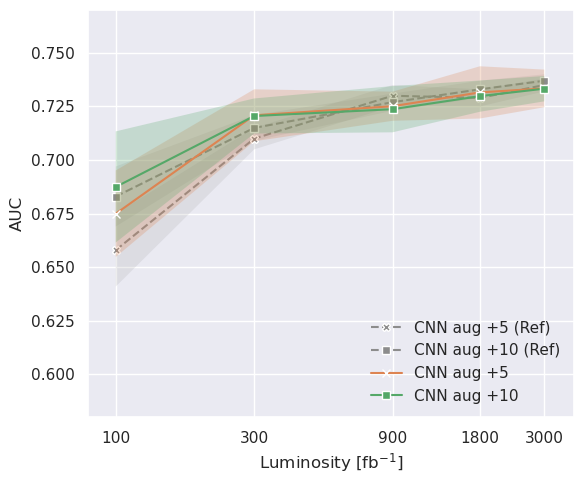

In [7]:
colors = {
    'CNN': '#4C72B0',          # 新的 CNN (藍)
    'CNN aug 5': '#DD8452',    # 新的 CNN aug 5 (橘)
    'CNN aug 10': '#55A868',   # 新的 CNN aug 10 (綠)
    'CNN Ref': '#8C8C8C'       # 舊的參考數據 (灰色)
}

fig, ax = plt.subplots(figsize=(6, 5))

# --- 1. 繪製舊有參考資料 (Reference from previous image) ---
# 舊的 CNN 基準線 (使用虛線與方形 marker 以做區別)
# ax.plot(x_vals, plot_a_orig_mean, marker='o', color=colors['CNN Ref'], linestyle='--', 
#         label='CNN (Ref)', markersize=6, markeredgecolor='white', zorder=4)
# ax.fill_between(x_vals, plot_a_orig_mean - plot_a_orig_std, plot_a_orig_mean + plot_a_orig_std, 
#                 color=colors['CNN Ref'], alpha=0.15, edgecolor='none', zorder=3)

ax.plot(x_vals, plot_a_aug5_mean, marker='X', color=colors['CNN Ref'], linestyle='--', 
        label='CNN aug +5 (Ref)', markersize=6, markeredgecolor='white', zorder=4)
ax.fill_between(x_vals, plot_a_aug5_mean - plot_a_aug5_std, plot_a_aug5_mean + plot_a_aug5_std, 
                color=colors['CNN Ref'], alpha=0.15, edgecolor='none', zorder=3)

ax.plot(x_vals, plot_a_aug10_mean, marker='s', color=colors['CNN Ref'], linestyle='--',
        label='CNN aug +10 (Ref)', markersize=6, markeredgecolor='white', zorder=4)
ax.fill_between(x_vals, plot_a_aug10_mean - plot_a_aug10_std, plot_a_aug10_mean + plot_a_aug10_std, 
                color=colors['CNN Ref'], alpha=0.15, edgecolor='none', zorder=3)



# --- 2. 繪製現在的訓練結果 (Current training results) ---
# 新的 CNN (實線 + 圓形 marker)
# ax.plot(x_vals, cnn_a_mean, marker='o', color=colors['CNN'], 
#         label='CNN (New)', markersize=6, markeredgecolor='white', zorder=6)
# ax.fill_between(x_vals, cnn_a_mean - cnn_a_std, cnn_a_mean + cnn_a_std, 
#                 color=colors['CNN'], alpha=0.25, edgecolor='none', zorder=5)

# 新的 CNN aug 5
ax.plot(x_vals, cnn_a_aug_5_mean, marker='x', color=colors['CNN aug 5'], 
        label='CNN aug +5', markersize=6, markeredgecolor='white', zorder=6)
ax.fill_between(x_vals, cnn_a_aug_5_mean - cnn_a_aug_5_std, cnn_a_aug_5_mean + cnn_a_aug_5_std, 
                color=colors['CNN aug 5'], alpha=0.25, edgecolor='none', zorder=5)

# 新的 CNN aug 10
ax.plot(x_vals, cnn_a_aug_10_mean, marker='s', color=colors['CNN aug 10'], 
        label='CNN aug +10', markersize=6, markeredgecolor='white', zorder=6)
ax.fill_between(x_vals, cnn_a_aug_10_mean - cnn_a_aug_10_std, cnn_a_aug_10_mean + cnn_a_aug_10_std, 
                color=colors['CNN aug 10'], alpha=0.25, edgecolor='none', zorder=5)

ax.set_xscale('log')

ax.set_xlim(80, 3800)
ax.set_ylim(0.58, 0.77)

# 指定刻度的位置與文字標籤 (避免 log 尺度自動把標籤變成 10^2 等科學記號)
ax.set_xticks(x_vals)
ax.set_xticklabels(x_labels)

ax.set_xlabel('Luminosity [fb$^{-1}$]', fontsize=12)
ax.set_ylabel('AUC', fontsize=12)

# 圖例設定
ax.legend(loc='lower right', frameon=False, fontsize=11)

plt.tight_layout()
plt.show()
# plt.savefig(filename, format='pdf', bbox_inches='tight')
plt.close(fig)

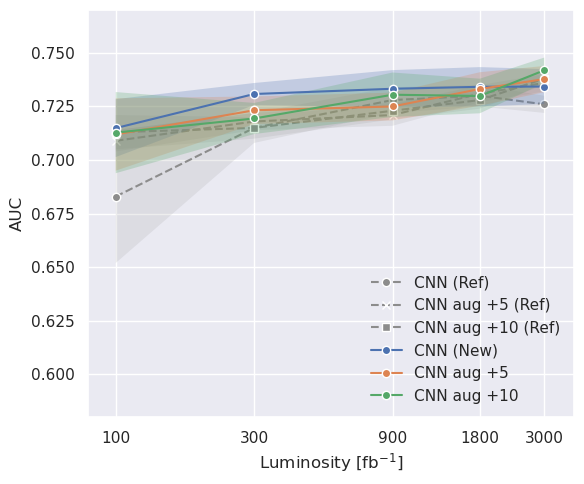

In [8]:
colors = {
    'CNN': '#4C72B0',          # 新的 CNN (藍)
    'CNN aug 5': '#DD8452',    # 新的 CNN aug 5 (橘)
    'CNN aug 10': '#55A868',   # 新的 CNN aug 10 (綠)
    'CNN Ref': '#8C8C8C'       # 舊的參考數據 (灰色)
}

fig, ax = plt.subplots(figsize=(6, 5))

# --- 1. 繪製舊有參考資料 (Reference from previous image) ---
# 舊的 CNN 基準線 (使用虛線與方形 marker 以做區別)
ax.plot(x_vals, plot_b_orig_mean, marker='o', color=colors['CNN Ref'], linestyle='--', 
        label='CNN (Ref)', markersize=6, markeredgecolor='white', zorder=4)
ax.fill_between(x_vals, plot_b_orig_mean - plot_b_orig_std, plot_b_orig_mean + plot_b_orig_std, 
                color=colors['CNN Ref'], alpha=0.15, edgecolor='none', zorder=3)

ax.plot(x_vals, plot_b_aug5_mean, marker='x', color=colors['CNN Ref'], linestyle='--', 
        label='CNN aug +5 (Ref)', markersize=6, markeredgecolor='white', zorder=4)
ax.fill_between(x_vals, plot_b_aug5_mean - plot_b_aug5_std, plot_b_aug5_mean + plot_b_aug5_std, 
                color=colors['CNN Ref'], alpha=0.15, edgecolor='none', zorder=3)

ax.plot(x_vals, plot_b_aug10_mean, marker='s', color=colors['CNN Ref'], linestyle='--',
        label='CNN aug +10 (Ref)', markersize=6, markeredgecolor='white', zorder=4)
ax.fill_between(x_vals, plot_b_aug10_mean - plot_b_aug10_std, plot_b_aug10_mean + plot_b_aug10_std, 
                color=colors['CNN Ref'], alpha=0.15, edgecolor='none', zorder=3)



# --- 2. 繪製現在的訓練結果 (Current training results) ---
# 新的 CNN (實線 + 圓形 marker)
ax.plot(x_vals, cnn_b_mean, marker='o', color=colors['CNN'], 
        label='CNN (New)', markersize=6, markeredgecolor='white', zorder=6)
ax.fill_between(x_vals, cnn_b_mean - cnn_b_std, cnn_b_mean + cnn_b_std, 
                color=colors['CNN'], alpha=0.25, edgecolor='none', zorder=5)

# 新的 CNN aug 5
ax.plot(x_vals, cnn_b_aug_5_mean, marker='o', color=colors['CNN aug 5'], 
        label='CNN aug +5', markersize=6, markeredgecolor='white', zorder=6)
ax.fill_between(x_vals, cnn_b_aug_5_mean - cnn_b_aug_5_std, cnn_b_aug_5_mean + cnn_b_aug_5_std, 
                color=colors['CNN aug 5'], alpha=0.25, edgecolor='none', zorder=5)

# 新的 CNN aug 10
ax.plot(x_vals, cnn_b_aug_10_mean, marker='o', color=colors['CNN aug 10'], 
        label='CNN aug +10', markersize=6, markeredgecolor='white', zorder=6)
ax.fill_between(x_vals, cnn_b_aug_10_mean - cnn_b_aug_10_std, cnn_b_aug_10_mean + cnn_b_aug_10_std, 
                color=colors['CNN aug 10'], alpha=0.25, edgecolor='none', zorder=5)

ax.set_xscale('log')

ax.set_xlim(80, 3800)
ax.set_ylim(0.58, 0.77)

# 指定刻度的位置與文字標籤 (避免 log 尺度自動把標籤變成 10^2 等科學記號)
ax.set_xticks(x_vals)
ax.set_xticklabels(x_labels)

ax.set_xlabel('Luminosity [fb$^{-1}$]', fontsize=12)
ax.set_ylabel('AUC', fontsize=12)

# 圖例設定
ax.legend(loc='lower right', frameon=False, fontsize=11)

plt.tight_layout()
plt.show()
# plt.savefig(filename, format='pdf', bbox_inches='tight')
plt.close(fig)

## Ideal mixture

In [9]:
# 設定與圖片一致的 seaborn 樣式 (預設為無襯線字體)
sns.set_theme(style="darkgrid")

# 定義 X 軸實際數值與標籤 (改用真實數值以便正確映射 log 尺度)
x_vals = np.array([100, 300, 900, 1800, 3000])
x_labels = ['100', '300', '900', '1800', '3000']

# --- DATA  ---
# (a) With photon information
cnn_fs_a_old = 0.873
cnn_a_mean_old = np.array([0.621, 0.686, 0.725, 0.736, 0.738])
cnn_a_std_old  = np.array([0.025, 0.010, 0.005, 0.004, 0.004])

sample_type = f'pure, aa, w/ decay product'
cnn_fs_a_mean, cnn_fs_a_std = get_AUC_and_error(df, sample_type)

cnn_a_mean, cnn_a_std = [], []
for l in [100, 300, 900, 1800, 3000]:
    sample_type = f'quark jet: = 2, L: {l} fb^-1, aa, w/ decay product'
    mean_AUC, std_AUC = get_AUC_and_error(df, sample_type)
    cnn_a_mean.append(mean_AUC)
    cnn_a_std.append(std_AUC)
cnn_a_mean, cnn_a_std = np.array(cnn_a_mean), np.array(cnn_a_std)

cnn_ideal_a_mean, cnn_ideal_a_std = [], []
for l in [100, 300, 900, 1800, 3000]:
    sample_type = f'quark jet: = 2, L: {l} fb^-1, aa, w/ decay product, ideal mixture'
    mean_AUC, std_AUC = get_AUC_and_error(df, sample_type)
    cnn_ideal_a_mean.append(mean_AUC)
    cnn_ideal_a_std.append(std_AUC)
cnn_ideal_a_mean, cnn_ideal_a_std = np.array(cnn_ideal_a_mean), np.array(cnn_ideal_a_std)


# (b) Without photon information
cnn_fs_b_old = 0.868
cnn_b_mean_old = np.array([0.682, 0.714, 0.726, 0.730, 0.725])
cnn_b_std_old  = np.array([0.020, 0.015, 0.008, 0.006, 0.006])

sample_type = f'pure, aa, w/o decay product'
cnn_fs_b_mean, cnn_fs_b_std = get_AUC_and_error(df, sample_type)

cnn_b_mean, cnn_b_std = [], []
for l in [100, 300, 900, 1800, 3000]:
    sample_type = f'quark jet: = 2, L: {l} fb^-1, aa, w/o decay product'
    mean_AUC, std_AUC = get_AUC_and_error(df, sample_type)
    cnn_b_mean.append(mean_AUC)
    cnn_b_std.append(std_AUC)
cnn_b_mean, cnn_b_std = np.array(cnn_b_mean), np.array(cnn_b_std)

cnn_ideal_b_mean, cnn_ideal_b_std = [], []
for l in [100, 300, 900, 1800, 3000]:
    sample_type = f'quark jet: = 2, L: {l} fb^-1, aa, w/o decay product, ideal mixture'
    mean_AUC, std_AUC = get_AUC_and_error(df, sample_type)
    cnn_ideal_b_mean.append(mean_AUC)
    cnn_ideal_b_std.append(std_AUC)
cnn_ideal_b_mean, cnn_ideal_b_std = np.array(cnn_ideal_b_mean), np.array(cnn_ideal_b_std)

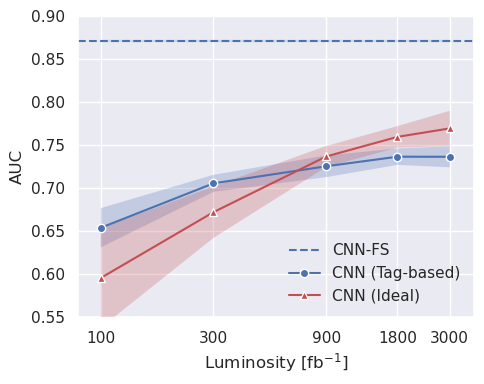

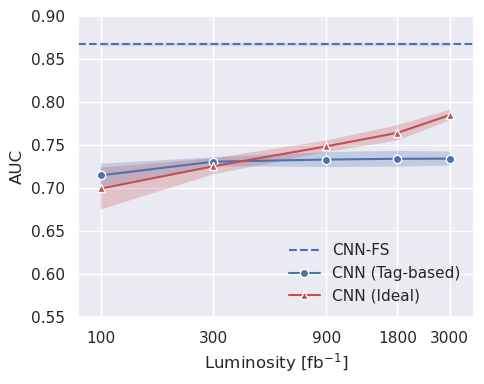

In [10]:
# 定義顏色
colors = {'CNN': '#4C72B0',
          'CNN_old': '#55A868',
          'CNN_ideal': '#C44E52',
          'ParT': '#DD8452'}

fig, ax = plt.subplots(figsize=(5, 4))

# 繪製新結果
ax.axhline(y=cnn_fs_a_mean, color=colors['CNN'], linestyle='--', label='CNN-FS', zorder=2)
ax.fill_between(x_vals, cnn_fs_a_mean - cnn_fs_a_std, cnn_fs_a_mean + cnn_fs_a_std, color=colors['CNN'], alpha=0.1, zorder=1)

ax.plot(x_vals, cnn_a_mean, marker='o', color=colors['CNN'], label='CNN (Tag-based)', markersize=6, markeredgecolor='white', zorder=4)
ax.fill_between(x_vals, cnn_a_mean - cnn_a_std, cnn_a_mean + cnn_a_std, color=colors['CNN'], alpha=0.25, edgecolor='none', zorder=3)

ax.plot(x_vals, cnn_ideal_a_mean, marker='^', color=colors['CNN_ideal'], label='CNN (Ideal)', markersize=6, markeredgecolor='white', zorder=4)
ax.fill_between(x_vals, cnn_ideal_a_mean - cnn_ideal_a_std, cnn_ideal_a_mean + cnn_ideal_a_std, color=colors['CNN_ideal'], alpha=0.25, edgecolor='none', zorder=3)

ax.set_xscale('log')

ax.set_xlim(80, 3800)
ax.set_ylim(0.55, 0.90)

# 指定刻度的位置與文字標籤 (避免 log 尺度自動把標籤變成 10^2 等科學記號)
ax.set_xticks(x_vals)
ax.set_xticklabels(x_labels)

ax.set_xlabel('Luminosity [fb$^{-1}$]', fontsize=12)
ax.set_ylabel('AUC', fontsize=12)

# 圖例設定
ax.legend(loc='lower right', frameon=False, fontsize=11)

plt.tight_layout()
plt.savefig('../figures/AUC_tag-based-vs-ideal_CWoLa_w_diphoton.pdf', dpi=300, facecolor='White', bbox_inches='tight')
plt.show()
plt.close(fig)


fig, ax = plt.subplots(figsize=(5, 4))
# 繪製新結果
ax.axhline(y=cnn_fs_b_mean, color=colors['CNN'], linestyle='--', label='CNN-FS', zorder=2)
ax.fill_between(x_vals, cnn_fs_b_mean - cnn_fs_b_std, cnn_fs_b_mean + cnn_fs_b_std, color=colors['CNN'], alpha=0.1, zorder=1)

ax.plot(x_vals, cnn_b_mean, marker='o', color=colors['CNN'], label='CNN (Tag-based)', markersize=6, markeredgecolor='white', zorder=4)
ax.fill_between(x_vals, cnn_b_mean - cnn_b_std, cnn_b_mean + cnn_b_std, color=colors['CNN'], alpha=0.25, edgecolor='none', zorder=3)

ax.plot(x_vals, cnn_ideal_b_mean, marker='^', color=colors['CNN_ideal'], label='CNN (Ideal)', markersize=6, markeredgecolor='white', zorder=4)
ax.fill_between(x_vals, cnn_ideal_b_mean - cnn_ideal_b_std, cnn_ideal_b_mean + cnn_ideal_b_std, color=colors['CNN_ideal'], alpha=0.25, edgecolor='none', zorder=3)

ax.set_xscale('log')

ax.set_xlim(80, 3800)
ax.set_ylim(0.55, 0.90)

# 指定刻度的位置與文字標籤 (避免 log 尺度自動把標籤變成 10^2 等科學記號)
ax.set_xticks(x_vals)
ax.set_xticklabels(x_labels)

ax.set_xlabel('Luminosity [fb$^{-1}$]', fontsize=12)
ax.set_ylabel('AUC', fontsize=12)

# 圖例設定
ax.legend(loc='lower right', frameon=False, fontsize=11)

plt.tight_layout()
plt.savefig('../figures/AUC_tag-based-vs-ideal_CWoLa_wo_diphoton.pdf', dpi=300, facecolor='White', bbox_inches='tight')
plt.show()
plt.close(fig)

# $H \to ZZ \to 4\ell$ channel

## Luminosity =  100, 300, 900, 1800, 3000, 9000, 18000, 30000 $\text{fb}^{-1}$

# Sanity check

In [11]:
file_name = './GGF_VBF_training_results.csv'
df = pd.read_csv(file_name)
df = df.query("time > '2026-03-18' and time < '2026-03-22'")

In [12]:
# 設定與圖片一致的 seaborn 樣式 (預設為無襯線字體)
sns.set_theme(style="darkgrid")

# 定義 X 軸實際數值與標籤 (改用真實數值以便正確映射 log 尺度)
x_vals = np.array([100, 300, 900, 1800, 3000])
x_labels = ['100', '300', '900', '1800', '3000']

# --- DATA  ---
# (a) With photon information

cnn_a_mean, cnn_a_std = [], []
for l in [100, 300, 900, 1800, 3000]:
    sample_type = f'quark jet: = 2, L: {l} fb^-1, aa, w/ decay product'

    mean_AUC, std_AUC = get_AUC_and_error(df, sample_type)
    cnn_a_mean.append(mean_AUC)
    cnn_a_std.append(std_AUC)

cnn_a_mean, cnn_a_std = np.array(cnn_a_mean), np.array(cnn_a_std)

cnn_a_aug_5_mean, cnn_a_aug_5_std = [], []
for l in [100, 300, 900, 1800, 3000]:
    sample_type = f'quark jet: = 2, L: {l} fb^-1, aa, w/ decay product, phi shifting: +5'
    mean_AUC, std_AUC = get_AUC_and_error(df, sample_type)
    cnn_a_aug_5_mean.append(mean_AUC)
    cnn_a_aug_5_std.append(std_AUC)
cnn_a_aug_5_mean, cnn_a_aug_5_std = np.array(cnn_a_aug_5_mean), np.array(cnn_a_aug_5_std)

cnn_a_dup_5_mean, cnn_a_dup_5_std = [], []
for l in [100, 300, 900, 1800, 3000]:
    sample_type = f'quark jet: = 2, L: {l} fb^-1, aa, w/ decay product, duplicating: +5'
    mean_AUC, std_AUC = get_AUC_and_error(df, sample_type)
    cnn_a_dup_5_mean.append(mean_AUC)
    cnn_a_dup_5_std.append(std_AUC)
cnn_a_dup_5_mean, cnn_a_dup_5_std = np.array(cnn_a_dup_5_mean), np.array(cnn_a_dup_5_std)

# (b) Without photon information

cnn_b_mean, cnn_b_std = [], []
for l in [100, 300, 900, 1800, 3000]:
    sample_type = f'quark jet: = 2, L: {l} fb^-1, aa, w/o decay product'
    mean_AUC, std_AUC = get_AUC_and_error(df, sample_type)
    cnn_b_mean.append(mean_AUC)
    cnn_b_std.append(std_AUC)
cnn_b_mean, cnn_b_std = np.array(cnn_b_mean), np.array(cnn_b_std)

cnn_b_aug_5_mean, cnn_b_aug_5_std = [], []
for l in [100, 300, 900, 1800, 3000]:
    sample_type = f'quark jet: = 2, L: {l} fb^-1, aa, w/o decay product, phi shifting: +5'
    mean_AUC, std_AUC = get_AUC_and_error(df, sample_type)
    cnn_b_aug_5_mean.append(mean_AUC)
    cnn_b_aug_5_std.append(std_AUC)
cnn_b_aug_5_mean, cnn_b_aug_5_std = np.array(cnn_b_aug_5_mean), np.array(cnn_b_aug_5_std)

cnn_b_dup_5_mean, cnn_b_dup_5_std = [], []
for l in [100, 300, 900, 1800, 3000]:
    sample_type = f'quark jet: = 2, L: {l} fb^-1, aa, w/o decay product, duplicating: +5'
    mean_AUC, std_AUC = get_AUC_and_error(df, sample_type)
    cnn_b_dup_5_mean.append(mean_AUC)
    cnn_b_dup_5_std.append(std_AUC)
cnn_b_dup_5_mean, cnn_b_dup_5_std = np.array(cnn_b_dup_5_mean), np.array(cnn_b_dup_5_std)

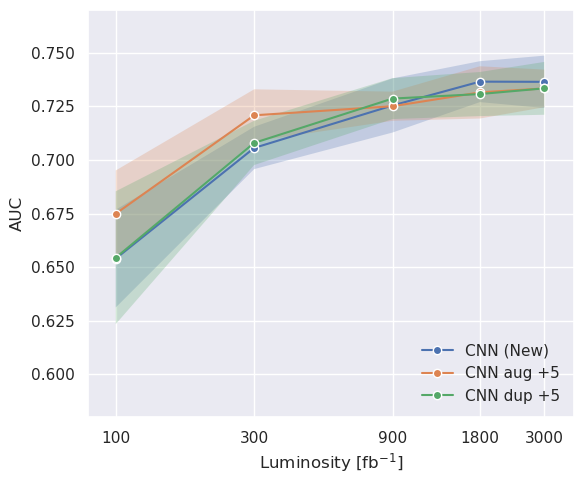

In [13]:
colors = {
    'CNN': '#4C72B0',          # 新的 CNN (藍)
    'CNN aug 5': '#DD8452',    # 新的 CNN aug 5 (橘)
    'CNN dup 5': '#55A868',   # 新的 CNN dup 5 (綠)
    # 'CNN Ref': '#8C8C8C'       # 舊的參考數據 (灰色)
}

fig, ax = plt.subplots(figsize=(6, 5))

# --- 1. 繪製舊有參考資料 (Reference from previous image) ---


# --- 2. 繪製現在的訓練結果 (Current training results) ---
# 新的 CNN (實線 + 圓形 marker)
ax.plot(x_vals, cnn_a_mean, marker='o', color=colors['CNN'], 
        label='CNN (New)', markersize=6, markeredgecolor='white', zorder=6)
ax.fill_between(x_vals, cnn_a_mean - cnn_a_std, cnn_a_mean + cnn_a_std, 
                color=colors['CNN'], alpha=0.25, edgecolor='none', zorder=5)

# 新的 CNN aug 5
ax.plot(x_vals, cnn_a_aug_5_mean, marker='o', color=colors['CNN aug 5'], 
        label='CNN aug +5', markersize=6, markeredgecolor='white', zorder=6)
ax.fill_between(x_vals, cnn_a_aug_5_mean - cnn_a_aug_5_std, cnn_a_aug_5_mean + cnn_a_aug_5_std, 
                color=colors['CNN aug 5'], alpha=0.25, edgecolor='none', zorder=5)

# 新的 CNN dup 5
ax.plot(x_vals, cnn_a_dup_5_mean, marker='o', color=colors['CNN dup 5'], 
        label='CNN dup +5', markersize=6, markeredgecolor='white', zorder=6)
ax.fill_between(x_vals, cnn_a_dup_5_mean - cnn_a_dup_5_std, cnn_a_dup_5_mean + cnn_a_dup_5_std, 
                color=colors['CNN dup 5'], alpha=0.25, edgecolor='none', zorder=5)

ax.set_xscale('log')

ax.set_xlim(80, 3800)
ax.set_ylim(0.58, 0.77)

# 指定刻度的位置與文字標籤 (避免 log 尺度自動把標籤變成 10^2 等科學記號)
ax.set_xticks(x_vals)
ax.set_xticklabels(x_labels)

ax.set_xlabel('Luminosity [fb$^{-1}$]', fontsize=12)
ax.set_ylabel('AUC', fontsize=12)

# 圖例設定
ax.legend(loc='lower right', frameon=False, fontsize=11)

plt.tight_layout()
plt.show()
# plt.savefig(filename, format='pdf', bbox_inches='tight')
plt.close(fig)

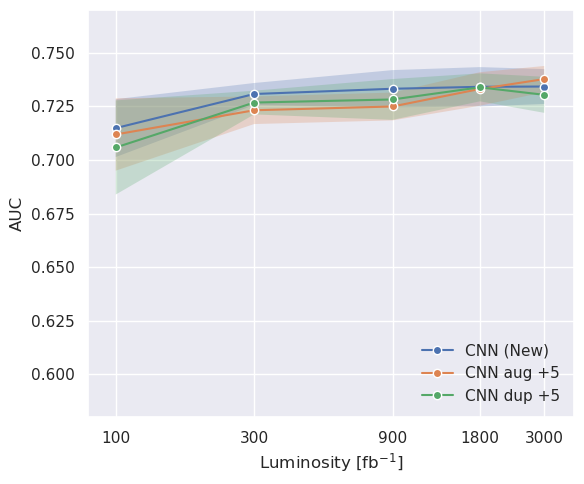

In [14]:
colors = {
    'CNN': '#4C72B0',          # 新的 CNN (藍)
    'CNN aug 5': '#DD8452',    # 新的 CNN aug 5 (橘)
    'CNN dup 5': '#55A868',   # 新的 CNN dup 5 (綠)
    'CNN Ref': '#8C8C8C'       # 舊的參考數據 (灰色)
}

fig, ax = plt.subplots(figsize=(6, 5))

# --- 1. 繪製舊有參考資料 (Reference from previous image) ---
# 舊的 CNN 基準線 (使用虛線與方形 marker 以做區別)


# --- 2. 繪製現在的訓練結果 (Current training results) ---
# 新的 CNN (實線 + 圓形 marker)
ax.plot(x_vals, cnn_b_mean, marker='o', color=colors['CNN'], 
        label='CNN (New)', markersize=6, markeredgecolor='white', zorder=6)
ax.fill_between(x_vals, cnn_b_mean - cnn_b_std, cnn_b_mean + cnn_b_std, 
                color=colors['CNN'], alpha=0.25, edgecolor='none', zorder=5)

# 新的 CNN aug 5
ax.plot(x_vals, cnn_b_aug_5_mean, marker='o', color=colors['CNN aug 5'], 
        label='CNN aug +5', markersize=6, markeredgecolor='white', zorder=6)
ax.fill_between(x_vals, cnn_b_aug_5_mean - cnn_b_aug_5_std, cnn_b_aug_5_mean + cnn_b_aug_5_std, 
                color=colors['CNN aug 5'], alpha=0.25, edgecolor='none', zorder=5)

# 新的 CNN dup 5
ax.plot(x_vals, cnn_b_dup_5_mean, marker='o', color=colors['CNN dup 5'], 
        label='CNN dup +5', markersize=6, markeredgecolor='white', zorder=6)
ax.fill_between(x_vals, cnn_b_dup_5_mean - cnn_b_dup_5_std, cnn_b_dup_5_mean + cnn_b_dup_5_std, 
                color=colors['CNN dup 5'], alpha=0.25, edgecolor='none', zorder=5)

ax.set_xscale('log')

ax.set_xlim(80, 3800)
ax.set_ylim(0.58, 0.77)

# 指定刻度的位置與文字標籤 (避免 log 尺度自動把標籤變成 10^2 等科學記號)
ax.set_xticks(x_vals)
ax.set_xticklabels(x_labels)

ax.set_xlabel('Luminosity [fb$^{-1}$]', fontsize=12)
ax.set_ylabel('AUC', fontsize=12)

# 圖例設定
ax.legend(loc='lower right', frameon=False, fontsize=11)

plt.tight_layout()
plt.show()
# plt.savefig(filename, format='pdf', bbox_inches='tight')
plt.close(fig)

# Ablation study: $H \to \gamma\gamma$ channel, using the samples without preprocessing

## Luminosity =  100, 300, 900, 1800, 3000 $\text{fb}^{-1}$

In [15]:
file_name = './GGF_VBF_training_results.csv'
df = pd.read_csv(file_name)
# df = df.query("time > '2026-03-18' and time < '2026-03-22'")

In [16]:
# 設定與圖片一致的 seaborn 樣式 (預設為無襯線字體)
sns.set_theme(style="darkgrid")

# 定義 X 軸實際數值與標籤 (改用真實數值以便正確映射 log 尺度)
x_vals = np.array([100, 300, 900, 1800, 3000])
x_labels = ['100', '300', '900', '1800', '3000']

# --- DATA  ---
# (a) With photon information

cnn_a_mean, cnn_a_std = [], []
for l in [100, 300, 900, 1800, 3000]:
    sample_type = f'quark jet: = 2, L: {l} fb^-1, aa, w/ decay product'

    mean_AUC, std_AUC = get_AUC_and_error(df, sample_type)
    cnn_a_mean.append(mean_AUC)
    cnn_a_std.append(std_AUC)

cnn_a_mean, cnn_a_std = np.array(cnn_a_mean), np.array(cnn_a_std)

sample_type = f'pure, aa, w/ decay product'
cnn_fs_a_mean, cnn_fs_a_std = get_AUC_and_error(df, sample_type)

cnn_a_flip_mean, cnn_a_flip_std = [], []
for l in [100, 300, 900, 1800, 3000]:
    sample_type = f'quark jet: = 2, L: {l} fb^-1, aa, w/ decay product, flipping only'

    mean_AUC, std_AUC = get_AUC_and_error(df, sample_type)
    cnn_a_flip_mean.append(mean_AUC)
    cnn_a_flip_std.append(std_AUC)

cnn_a_flip_mean, cnn_a_flip_std = np.array(cnn_a_flip_mean), np.array(cnn_a_flip_std)


# (b) Without photon information
cnn_b_mean, cnn_b_std = [], []
for l in [100, 300, 900, 1800, 3000]:
    sample_type = f'quark jet: = 2, L: {l} fb^-1, aa, w/o decay product'

    mean_AUC, std_AUC = get_AUC_and_error(df, sample_type)
    cnn_b_mean.append(mean_AUC)
    cnn_b_std.append(std_AUC)

cnn_b_mean, cnn_b_std = np.array(cnn_b_mean), np.array(cnn_b_std)

cnn_b_flip_mean, cnn_b_flip_std = [], []
for l in [100, 300, 900, 1800, 3000]:
    sample_type = f'quark jet: = 2, L: {l} fb^-1, aa, w/o decay product, flipping only'

    mean_AUC, std_AUC = get_AUC_and_error(df, sample_type)
    cnn_b_flip_mean.append(mean_AUC)
    cnn_b_flip_std.append(std_AUC)

cnn_b_flip_mean, cnn_b_flip_std = np.array(cnn_b_flip_mean), np.array(cnn_b_flip_std)

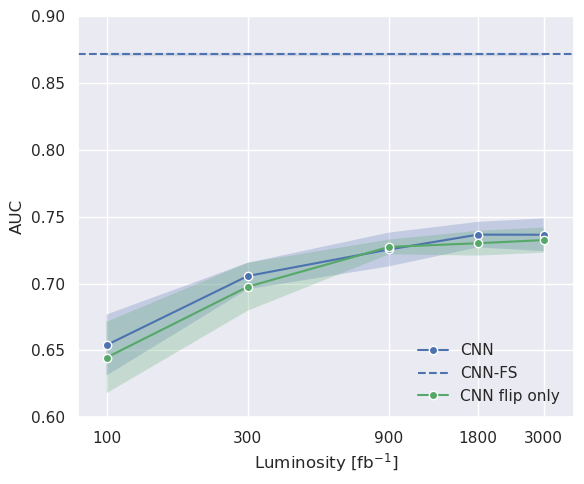

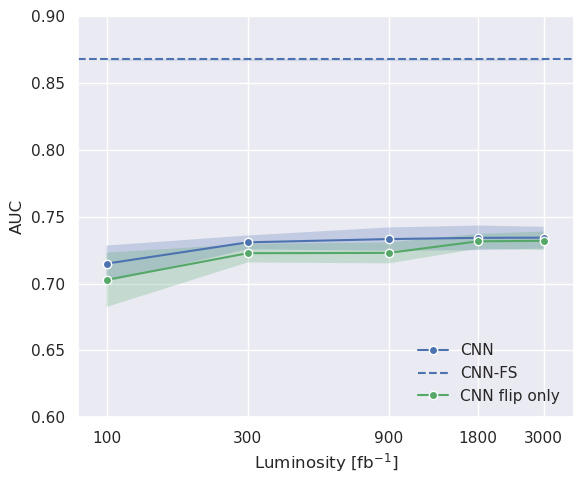

In [17]:
# 定義顏色
colors = {'CNN': '#4C72B0',
          'CNN flip': '#55A868',
        'ParT': '#DD8452'}

fig, ax = plt.subplots(figsize=(6, 5))


# 繪製新結果
ax.plot(x_vals, cnn_a_mean, marker='o', color=colors['CNN'], label='CNN', markersize=6, markeredgecolor='white', zorder=4)
ax.fill_between(x_vals, cnn_a_mean - cnn_a_std, cnn_a_mean + cnn_a_std, color=colors['CNN'], alpha=0.25, edgecolor='none', zorder=3)

ax.axhline(y=cnn_fs_a_mean, color=colors['CNN'], linestyle='--', label='CNN-FS', zorder=2)
ax.fill_between(x_vals, cnn_fs_a_mean - cnn_fs_a_std, cnn_fs_a_mean + cnn_fs_a_std, color=colors['CNN'], alpha=0.1, zorder=1)

ax.plot(x_vals, cnn_a_flip_mean, marker='o', color=colors['CNN flip'], label='CNN flip only', markersize=6, markeredgecolor='white', zorder=4)
ax.fill_between(x_vals, cnn_a_flip_mean - cnn_a_flip_std, cnn_a_flip_mean + cnn_a_flip_std, color=colors['CNN flip'], alpha=0.25,edgecolor='none', zorder=3)


ax.set_xscale('log')

ax.set_xlim(80, 3800)
ax.set_ylim(0.60, 0.90)

# 指定刻度的位置與文字標籤 (避免 log 尺度自動把標籤變成 10^2 等科學記號)
ax.set_xticks(x_vals)
ax.set_xticklabels(x_labels)

ax.set_xlabel('Luminosity [fb$^{-1}$]', fontsize=12)
ax.set_ylabel('AUC', fontsize=12)

# 圖例設定
ax.legend(loc='lower right', frameon=False, fontsize=11)

plt.tight_layout()
plt.show()
# plt.savefig(filename, format='pdf', bbox_inches='tight')
plt.close(fig)


fig, ax = plt.subplots(figsize=(6, 5))

# 繪製新結果
ax.plot(x_vals, cnn_b_mean, marker='o', color=colors['CNN'], label='CNN', markersize=6, markeredgecolor='white', zorder=4)
ax.fill_between(x_vals, cnn_b_mean - cnn_b_std, cnn_b_mean + cnn_b_std, color=colors['CNN'], alpha=0.25, edgecolor='none', zorder=3)

ax.axhline(y=cnn_fs_b_mean, color=colors['CNN'], linestyle='--', label='CNN-FS', zorder=2)
ax.fill_between(x_vals, cnn_fs_b_mean - cnn_fs_b_std, cnn_fs_b_mean + cnn_fs_b_std, color=colors['CNN'], alpha=0.1, zorder=1)

ax.plot(x_vals, cnn_b_flip_mean, marker='o', color=colors['CNN flip'], label='CNN flip only', markersize=6, markeredgecolor='white', zorder=4)
ax.fill_between(x_vals, cnn_b_flip_mean - cnn_b_flip_std, cnn_b_flip_mean + cnn_b_flip_std, color=colors['CNN flip'], alpha=0.25, edgecolor='none', zorder=3)

ax.set_xscale('log')

ax.set_xlim(80, 3800)
ax.set_ylim(0.60, 0.90)

# 指定刻度的位置與文字標籤 (避免 log 尺度自動把標籤變成 10^2 等科學記號)
ax.set_xticks(x_vals)
ax.set_xticklabels(x_labels)

ax.set_xlabel('Luminosity [fb$^{-1}$]', fontsize=12)
ax.set_ylabel('AUC', fontsize=12)

# 圖例設定
ax.legend(loc='lower right', frameon=False, fontsize=11)

plt.tight_layout()
plt.show()
# plt.savefig(filename, format='pdf', bbox_inches='tight')
plt.close(fig)

## Data augmentation

In [18]:
# 設定與圖片一致的 seaborn 樣式 (預設為無襯線字體)
sns.set_theme(style="darkgrid")

# 定義 X 軸實際數值與標籤 (改用真實數值以便正確映射 log 尺度)
x_vals = np.array([100, 300, 900, 1800, 3000])
x_labels = ['100', '300', '900', '1800', '3000']

# --- DATA  ---
# (a) With photon information

cnn_a_mean, cnn_a_std = [], []
for l in [100, 300, 900, 1800, 3000]:
    sample_type = f'quark jet: = 2, L: {l} fb^-1, aa, w/ decay product'

    mean_AUC, std_AUC = get_AUC_and_error(df, sample_type)
    cnn_a_mean.append(mean_AUC)
    cnn_a_std.append(std_AUC)

cnn_a_mean, cnn_a_std = np.array(cnn_a_mean), np.array(cnn_a_std)

cnn_a_aug_5_mean, cnn_a_aug_5_std = [], []
for l in [100, 300, 900, 1800, 3000]:
    sample_type = f'quark jet: = 2, L: {l} fb^-1, aa, w/ decay product, phi shifting: +5'
    mean_AUC, std_AUC = get_AUC_and_error(df, sample_type)
    cnn_a_aug_5_mean.append(mean_AUC)
    cnn_a_aug_5_std.append(std_AUC)
cnn_a_aug_5_mean, cnn_a_aug_5_std = np.array(cnn_a_aug_5_mean), np.array(cnn_a_aug_5_std)

cnn_a_aug_10_mean, cnn_a_aug_10_std = [], []
for l in [100, 300, 900, 1800, 3000]:
    sample_type = f'quark jet: = 2, L: {l} fb^-1, aa, w/ decay product, phi shifting: +10'
    mean_AUC, std_AUC = get_AUC_and_error(df, sample_type)
    cnn_a_aug_10_mean.append(mean_AUC)
    cnn_a_aug_10_std.append(std_AUC)
cnn_a_aug_10_mean, cnn_a_aug_10_std = np.array(cnn_a_aug_10_mean), np.array(cnn_a_aug_10_std)

cnn_a_aug_5_flip_mean, cnn_a_aug_5_flip_std = [], []
for l in [100, 300, 900, 1800, 3000]:
    sample_type = f'quark jet: = 2, L: {l} fb^-1, aa, w/ decay product, phi shifting: +5, flipping only'
    mean_AUC, std_AUC = get_AUC_and_error(df, sample_type)
    cnn_a_aug_5_flip_mean.append(mean_AUC)
    cnn_a_aug_5_flip_std.append(std_AUC)
cnn_a_aug_5_flip_mean, cnn_a_aug_5_flip_std = np.array(cnn_a_aug_5_flip_mean), np.array(cnn_a_aug_5_flip_std)

cnn_a_aug_10_flip_mean, cnn_a_aug_10_flip_std = [], []
for l in [100, 300, 900, 1800, 3000]:
    sample_type = f'quark jet: = 2, L: {l} fb^-1, aa, w/ decay product, phi shifting: +10, flipping only'
    mean_AUC, std_AUC = get_AUC_and_error(df, sample_type)
    cnn_a_aug_10_flip_mean.append(mean_AUC)
    cnn_a_aug_10_flip_std.append(std_AUC)
cnn_a_aug_10_flip_mean, cnn_a_aug_10_flip_std = np.array(cnn_a_aug_10_flip_mean), np.array(cnn_a_aug_10_flip_std)

# (b) Without photon information

cnn_b_mean, cnn_b_std = [], []
for l in [100, 300, 900, 1800, 3000]:
    sample_type = f'quark jet: = 2, L: {l} fb^-1, aa, w/o decay product'
    mean_AUC, std_AUC = get_AUC_and_error(df, sample_type)
    cnn_b_mean.append(mean_AUC)
    cnn_b_std.append(std_AUC)
cnn_b_mean, cnn_b_std = np.array(cnn_b_mean), np.array(cnn_b_std)

cnn_b_aug_5_mean, cnn_b_aug_5_std = [], []
for l in [100, 300, 900, 1800, 3000]:
    sample_type = f'quark jet: = 2, L: {l} fb^-1, aa, w/o decay product, phi shifting: +5'
    mean_AUC, std_AUC = get_AUC_and_error(df, sample_type)
    cnn_b_aug_5_mean.append(mean_AUC)
    cnn_b_aug_5_std.append(std_AUC)
cnn_b_aug_5_mean, cnn_b_aug_5_std = np.array(cnn_b_aug_5_mean), np.array(cnn_b_aug_5_std)

cnn_b_aug_10_mean, cnn_b_aug_10_std = [], []
for l in [100, 300, 900, 1800, 3000]:
    sample_type = f'quark jet: = 2, L: {l} fb^-1, aa, w/o decay product, phi shifting: +10'
    mean_AUC, std_AUC = get_AUC_and_error(df, sample_type)
    cnn_b_aug_10_mean.append(mean_AUC)
    cnn_b_aug_10_std.append(std_AUC)
cnn_b_aug_10_mean, cnn_b_aug_10_std = np.array(cnn_b_aug_10_mean), np.array(cnn_b_aug_10_std)

cnn_b_aug_5_flip_mean, cnn_b_aug_5_flip_std = [], []
for l in [100, 300, 900, 1800, 3000]:
    sample_type = f'quark jet: = 2, L: {l} fb^-1, aa, w/o decay product, phi shifting: +5, flipping only'
    mean_AUC, std_AUC = get_AUC_and_error(df, sample_type)
    cnn_b_aug_5_flip_mean.append(mean_AUC)
    cnn_b_aug_5_flip_std.append(std_AUC)
cnn_b_aug_5_flip_mean, cnn_b_aug_5_flip_std = np.array(cnn_b_aug_5_flip_mean), np.array(cnn_b_aug_5_flip_std)

cnn_b_aug_10_flip_mean, cnn_b_aug_10_flip_std = [], []
for l in [100, 300, 900, 1800, 3000]:
    sample_type = f'quark jet: = 2, L: {l} fb^-1, aa, w/o decay product, phi shifting: +10, flipping only'
    mean_AUC, std_AUC = get_AUC_and_error(df, sample_type)
    cnn_b_aug_10_flip_mean.append(mean_AUC)
    cnn_b_aug_10_flip_std.append(std_AUC)
cnn_b_aug_10_flip_mean, cnn_b_aug_10_flip_std = np.array(cnn_b_aug_10_flip_mean), np.array(cnn_b_aug_10_flip_std)

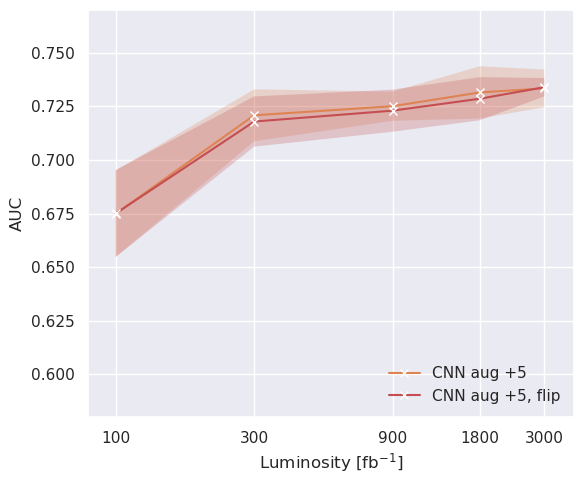

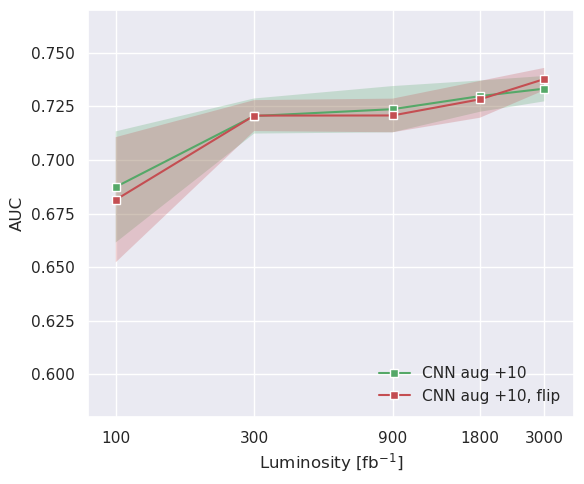

In [19]:
colors = {
    'CNN': '#4C72B0',          # 新的 CNN (藍)
    'CNN aug 5': '#DD8452',    # 新的 CNN aug 5 (橘)
    'CNN aug 10': '#55A868',   # 新的 CNN aug 10 (綠)
    'CNN flip': '#C44E52',     # 新的 CNN flip only (紅)
    'CNN Ref': '#8C8C8C'       # 舊的參考數據 (灰色)
}

fig, ax = plt.subplots(figsize=(6, 5))

# 新的 CNN aug 5
ax.plot(x_vals, cnn_a_aug_5_mean, marker='x', color=colors['CNN aug 5'], 
        label='CNN aug +5', markersize=6, markeredgecolor='white', zorder=6)
ax.fill_between(x_vals, cnn_a_aug_5_mean - cnn_a_aug_5_std, cnn_a_aug_5_mean + cnn_a_aug_5_std, 
                color=colors['CNN aug 5'], alpha=0.25, edgecolor='none', zorder=5)

ax.plot(x_vals, cnn_a_aug_5_flip_mean, marker='x', color=colors['CNN flip'], 
        label='CNN aug +5, flip', markersize=6, markeredgecolor='white', zorder=6)
ax.fill_between(x_vals, cnn_a_aug_5_flip_mean - cnn_a_aug_5_flip_std, cnn_a_aug_5_flip_mean + cnn_a_aug_5_flip_std, 
                color=colors['CNN flip'], alpha=0.25, edgecolor='none', zorder=5)

ax.set_xscale('log')

ax.set_xlim(80, 3800)
ax.set_ylim(0.58, 0.77)

# 指定刻度的位置與文字標籤 (避免 log 尺度自動把標籤變成 10^2 等科學記號)
ax.set_xticks(x_vals)
ax.set_xticklabels(x_labels)

ax.set_xlabel('Luminosity [fb$^{-1}$]', fontsize=12)
ax.set_ylabel('AUC', fontsize=12)

# 圖例設定
ax.legend(loc='lower right', frameon=False, fontsize=11)

plt.tight_layout()
plt.show()
# plt.savefig(filename, format='pdf', bbox_inches='tight')
plt.close(fig)

fig, ax = plt.subplots(figsize=(6, 5))

# 新的 CNN aug 10
ax.plot(x_vals, cnn_a_aug_10_mean, marker='s', color=colors['CNN aug 10'], 
        label='CNN aug +10', markersize=6, markeredgecolor='white', zorder=6)
ax.fill_between(x_vals, cnn_a_aug_10_mean - cnn_a_aug_10_std, cnn_a_aug_10_mean + cnn_a_aug_10_std, 
                color=colors['CNN aug 10'], alpha=0.25, edgecolor='none', zorder=5)

ax.plot(x_vals, cnn_a_aug_10_flip_mean, marker='s', color=colors['CNN flip'], 
        label='CNN aug +10, flip', markersize=6, markeredgecolor='white', zorder=6)
ax.fill_between(x_vals, cnn_a_aug_10_flip_mean - cnn_a_aug_10_flip_std, cnn_a_aug_10_flip_mean + cnn_a_aug_10_flip_std, 
                color=colors['CNN flip'], alpha=0.25, edgecolor='none', zorder=5)

ax.set_xscale('log')

ax.set_xlim(80, 3800)
ax.set_ylim(0.58, 0.77)

# 指定刻度的位置與文字標籤 (避免 log 尺度自動把標籤變成 10^2 等科學記號)
ax.set_xticks(x_vals)
ax.set_xticklabels(x_labels)

ax.set_xlabel('Luminosity [fb$^{-1}$]', fontsize=12)
ax.set_ylabel('AUC', fontsize=12)

# 圖例設定
ax.legend(loc='lower right', frameon=False, fontsize=11)

plt.tight_layout()
plt.show()
# plt.savefig(filename, format='pdf', bbox_inches='tight')
plt.close(fig)

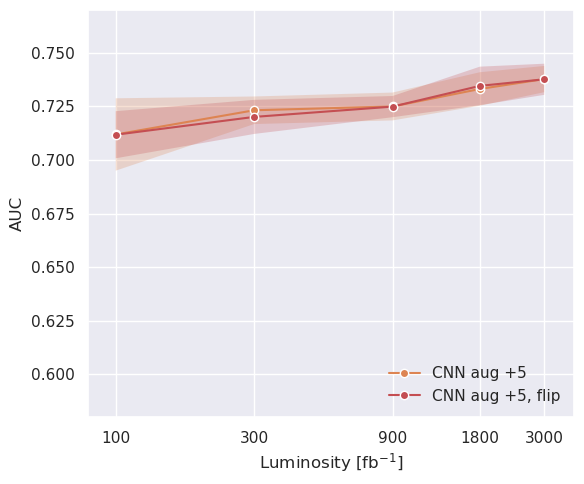

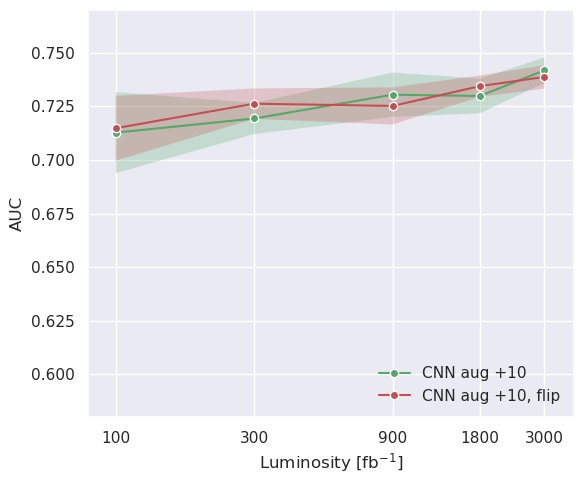

In [20]:
colors = {
    'CNN': '#4C72B0',          # 新的 CNN (藍)
    'CNN aug 5': '#DD8452',    # 新的 CNN aug 5 (橘)
    'CNN aug 10': '#55A868',   # 新的 CNN aug 10 (綠)
    'CNN flip': '#C44E52',     # 新的 CNN flip only (紅)
    'CNN Ref': '#8C8C8C'       # 舊的參考數據 (灰色)
}

fig, ax = plt.subplots(figsize=(6, 5))

# --- 2. 繪製現在的訓練結果 (Current training results) ---
# 新的 CNN aug 5
ax.plot(x_vals, cnn_b_aug_5_mean, marker='o', color=colors['CNN aug 5'], 
        label='CNN aug +5', markersize=6, markeredgecolor='white', zorder=6)
ax.fill_between(x_vals, cnn_b_aug_5_mean - cnn_b_aug_5_std, cnn_b_aug_5_mean + cnn_b_aug_5_std, 
                color=colors['CNN aug 5'], alpha=0.25, edgecolor='none', zorder=5)

ax.plot(x_vals, cnn_b_aug_5_flip_mean, marker='o', color=colors['CNN flip'], 
        label='CNN aug +5, flip', markersize=6, markeredgecolor='white', zorder=6)
ax.fill_between(x_vals, cnn_b_aug_5_flip_mean - cnn_b_aug_5_flip_std, cnn_b_aug_5_flip_mean + cnn_b_aug_5_flip_std, 
                color=colors['CNN flip'], alpha=0.25, edgecolor='none', zorder=5)

ax.set_xscale('log')

ax.set_xlim(80, 3800)
ax.set_ylim(0.58, 0.77)

# 指定刻度的位置與文字標籤 (避免 log 尺度自動把標籤變成 10^2 等科學記號)
ax.set_xticks(x_vals)
ax.set_xticklabels(x_labels)

ax.set_xlabel('Luminosity [fb$^{-1}$]', fontsize=12)
ax.set_ylabel('AUC', fontsize=12)

# 圖例設定
ax.legend(loc='lower right', frameon=False, fontsize=11)

plt.tight_layout()
plt.show()
# plt.savefig(filename, format='pdf', bbox_inches='tight')
plt.close(fig)

fig, ax = plt.subplots(figsize=(6, 5))

# 新的 CNN aug 10
ax.plot(x_vals, cnn_b_aug_10_mean, marker='o', color=colors['CNN aug 10'], 
        label='CNN aug +10', markersize=6, markeredgecolor='white', zorder=6)
ax.fill_between(x_vals, cnn_b_aug_10_mean - cnn_b_aug_10_std, cnn_b_aug_10_mean + cnn_b_aug_10_std, 
                color=colors['CNN aug 10'], alpha=0.25, edgecolor='none', zorder=5)

ax.plot(x_vals, cnn_b_aug_10_flip_mean, marker='o', color=colors['CNN flip'], 
        label='CNN aug +10, flip', markersize=6, markeredgecolor='white', zorder=6)
ax.fill_between(x_vals, cnn_b_aug_10_flip_mean - cnn_b_aug_10_flip_std, cnn_b_aug_10_flip_mean + cnn_b_aug_10_flip_std, 
                color=colors['CNN flip'], alpha=0.25, edgecolor='none', zorder=5)

ax.set_xscale('log')

ax.set_xlim(80, 3800)
ax.set_ylim(0.58, 0.77)

# 指定刻度的位置與文字標籤 (避免 log 尺度自動把標籤變成 10^2 等科學記號)
ax.set_xticks(x_vals)
ax.set_xticklabels(x_labels)

ax.set_xlabel('Luminosity [fb$^{-1}$]', fontsize=12)
ax.set_ylabel('AUC', fontsize=12)

# 圖例設定
ax.legend(loc='lower right', frameon=False, fontsize=11)

plt.tight_layout()
plt.show()
# plt.savefig(filename, format='pdf', bbox_inches='tight')
plt.close(fig)